In [1]:
print("hello")

hello


In [2]:
import pandas as pd
import json
import matplotlib.pyplot as plt
from collections import Counter

print("Skill Gap Analyzer ready!")

Skill Gap Analyzer ready!


In [8]:
# Load job data
df_jobs = pd.read_csv(r'C:\Users\KARAN DUBEY\career_navigator\data\clean_jobs.csv')

# Load resume data
with open(r'C:\Users\KARAN DUBEY\career_navigator\output\resume_parsed.json', 'r') as f:
    resume_data = json.load(f)

# Load top matches
top_matches = pd.read_csv(r'C:\Users\KARAN DUBEY\career_navigator\output\top_matches.csv')

print(f"Jobs loaded: {len(df_jobs)}")
print(f"Resume skills: {resume_data['skills']}")
print(f"Top matches loaded: {len(top_matches)}")

Jobs loaded: 10000
Resume skills: ['python', 'sql', 'excel', 'power bi', 'data analysis', 'pandas', 'numpy', 'matplotlib', 'r', 'mysql', 'postgresql', 'scikit-learn', 'git', 'leadership', 'time management', 'dax', 'cosine similarity', 'eda']
Top matches loaded: 10


In [13]:
# Find common skills in job descriptions
all_skills_in_jobs = [
    'python', 'sql', 'excel', 'power bi', 'tableau',
    'machine learning', 'data analysis', 'pandas', 'numpy',
    'matplotlib', 'statistics', 'r', 'spark', 'mysql',
    'postgresql', 'mongodb', 'data visualization', 'scikit-learn',
    'nlp', 'git', 'aws', 'azure', 'docker', 'linux',
    'communication', 'leadership', 'time management', 'dax',
    'tensorflow', 'keras', 'hadoop', 'hive', 'looker',
    'snowflake', 'airflow', 'etl', 'bi tools'
]

# Count how many times each skill is mentioned in jobs
job_text_all = ' '.join(df_jobs['description'].fillna('').tolist()).lower()

skill_demand = {}
for skill in all_skills_in_jobs:
    count = job_text_all.count(skill)
    if count > 0:
        skill_demand[skill] = count

# Sort by demand
skill_demand_sorted = dict(sorted(skill_demand.items(), 
                                   key=lambda x: x[1], reverse=True))

print("Top 15 most demanded skills in jobs:")
for i, (skill, count) in enumerate(list(skill_demand_sorted.items())[:15], 1):
    print(f"  {i}. {skill}: {count} jobs")

Top 15 most demanded skills in jobs:
  1. r: 2073540 jobs
  2. communication: 8365 jobs
  3. excel: 8167 jobs
  4. leadership: 3790 jobs
  5. aws: 3069 jobs
  6. git: 2325 jobs
  7. sql: 881 jobs
  8. time management: 697 jobs
  9. azure: 556 jobs
  10. python: 531 jobs
  11. data analysis: 334 jobs
  12. machine learning: 311 jobs
  13. statistics: 264 jobs
  14. linux: 194 jobs
  15. spark: 146 jobs


In [17]:
# Your skills
my_skills = set(resume_data['skills'])

# Top 15 demanded skills
top_demanded = set(list(skill_demand_sorted.keys())[:15])

# Find skill gap
skill_gap = top_demanded - my_skills
already_have = top_demanded & my_skills

print("="*50)
print("SKILL GAP ANALYSIS — KARAN DUBEY")
print("="*50)

print(f"\n✅ Skills you already have ({len(already_have)} skills):")
for skill in already_have:
    print(f"   ✓ {skill}")

print(f"\n❌ Skills you need to learn ({len(skill_gap)} skills):")
for skill in skill_gap:
    print(f"   ✗ {skill}")

print(f"\nYour score: {len(already_have)}/{len(top_demanded)} top skills")
percentage = (len(already_have)/len(top_demanded))*100
print(f"Match percentage: {percentage:.1f}%")

SKILL GAP ANALYSIS — KARAN DUBEY

✅ Skills you already have (8 skills):
   ✓ sql
   ✓ time management
   ✓ leadership
   ✓ excel
   ✓ python
   ✓ r
   ✓ git
   ✓ data analysis

❌ Skills you need to learn (7 skills):
   ✗ spark
   ✗ communication
   ✗ aws
   ✗ azure
   ✗ statistics
   ✗ linux
   ✗ machine learning

Your score: 8/15 top skills
Match percentage: 53.3%


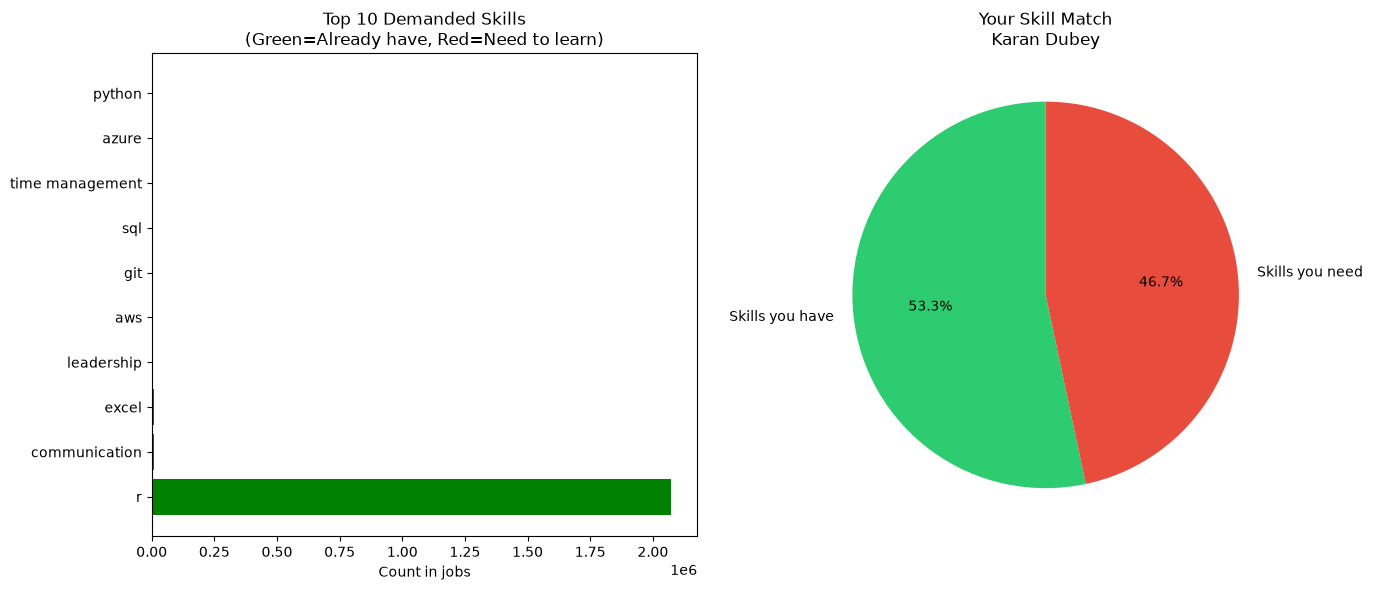

Chart saved successfully!


In [20]:
# Create bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 — Top 10 Demanded Skills
top_10_skills = list(skill_demand_sorted.keys())[:10]
top_10_counts = list(skill_demand_sorted.values())[:10]

colors = ['green' if skill in my_skills else 'red' for skill in top_10_skills]

ax1.barh(top_10_skills, top_10_counts, color=colors)
ax1.set_title('Top 10 Demanded Skills\n(Green=Already have, Red=Need to learn)')
ax1.set_xlabel('Count in jobs')

# Chart 2 — Your Skill Match
labels = ['Skills you have', 'Skills you need']
sizes = [len(already_have), len(skill_gap)]
colors2 = ['#2ecc71', '#e74c3c']

ax2.pie(sizes, labels=labels, colors=colors2, autopct='%1.1f%%', startangle=90)
ax2.set_title('Your Skill Match\nKaran Dubey')

plt.tight_layout()
plt.savefig(r'C:\Users\KARAN DUBEY\career_navigator\output\skill_gap_chart.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved successfully!")

In [22]:
# Suggest resources for missing skills
learning_resources = {
    'aws': 'https://aws.amazon.com/training/ (Free tier available)',
    'azure': 'https://learn.microsoft.com/azure (Microsoft Learn - Free)',
    'tableau': 'https://www.tableau.com/learn/training (Free training)',
    'spark': 'https://spark.apache.org/docs/ + Coursera',
    'docker': 'https://docs.docker.com/get-started/ (Free)',
    'tensorflow': 'https://www.tensorflow.org/tutorials (Free)',
    'communication': 'https://www.coursera.org/courses?query=communication',
    'statistics': 'https://www.khanacademy.org/math/statistics-probability'
}

print("="*55)
print("LEARNING ROADMAP — KARAN DUBEY")
print("="*55)

missing_with_resources = []
for skill in skill_gap:
    resource = learning_resources.get(skill, 'Search on Google/YouTube')
    missing_with_resources.append({
        'skill': skill,
        'resource': resource,
        'priority': 'High' if skill in ['aws', 'azure', 'tableau'] else 'Medium'
    })
    print(f"\n❌ {skill.upper()}")
    print(f"   Priority: {'🔴 High' if skill in ['aws', 'azure', 'tableau'] else '🟡 Medium'}")
    print(f"   Resource: {resource}")

# Save roadmap
resources_df = pd.DataFrame(missing_with_resources)
resources_df.to_csv(
    r'C:\Users\KARAN DUBEY\career_navigator\output\learning_roadmap.csv',
    index=False
)
print("\n✅ Learning roadmap saved successfully!")

LEARNING ROADMAP — KARAN DUBEY

❌ SPARK
   Priority: 🟡 Medium
   Resource: https://spark.apache.org/docs/ + Coursera

❌ COMMUNICATION
   Priority: 🟡 Medium
   Resource: https://www.coursera.org/courses?query=communication

❌ AWS
   Priority: 🔴 High
   Resource: https://aws.amazon.com/training/ (Free tier available)

❌ AZURE
   Priority: 🔴 High
   Resource: https://learn.microsoft.com/azure (Microsoft Learn - Free)

❌ STATISTICS
   Priority: 🟡 Medium
   Resource: https://www.khanacademy.org/math/statistics-probability

❌ LINUX
   Priority: 🟡 Medium
   Resource: Search on Google/YouTube

❌ MACHINE LEARNING
   Priority: 🟡 Medium
   Resource: Search on Google/YouTube

✅ Learning roadmap saved successfully!
